**SCENARIO 1  MULTINOMIAL NAÏVE BAYES**

Problem Statement
Classify SMS messages as Spam or Ham (Not Spam)..

Dataset (Kaggle  Public)
https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Target Variable: Message Label (Spam / Ham)
Input Feature: SMS Text Messages

IN-LAB TASKS (Multinomial Naïve Bayes)
1.	Import required Python libraries.
2.	Load the SMS Spam dataset.
3.	Perform data preprocessing:
•	Text cleaning (lowercase, punctuation removal)
•	Stopword removal (optional)
4.	Convert text into numerical features using:
•	Count Vectorization / TF-IDF
5.	Encode target labels.
6.	Split dataset into training and testing sets.
7.	Train a Multinomial Naïve Bayes classifier.
8.	Predict message classes.
9.	Evaluate performance using:
•	Accuracy
•	Precision
•	Recall
•	F1 Score
10.	Analyze misclassified examples.
11.	Apply Laplace smoothing and observe impact.

Visualization
• Confusion Matrix
• Feature importance (Top words influencing spam classification)
• Word frequency comparison (Spam vs Ham)


In [2]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1','v2']]
df.columns = ['label','message']
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [60]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['clean_msg'] = df['message'].apply(clean_text)


In [61]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['clean_msg'])


In [63]:
le = LabelEncoder()
y = le.fit_transform(df['label'])


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [66]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)


MultinomialNB()

In [67]:
y_pred = model.predict(X_test)


In [68]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))


Accuracy: 0.9704035874439462
Precision: 0.8774193548387097
Recall: 0.9066666666666666
F1 Score: 0.8918032786885246


In [69]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      0.98      0.98       965
           1       0.88      0.91      0.89       150

    accuracy                           0.97      1115
   macro avg       0.93      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115



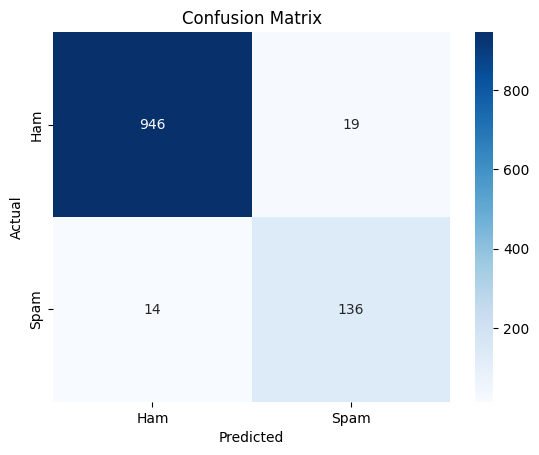

In [70]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


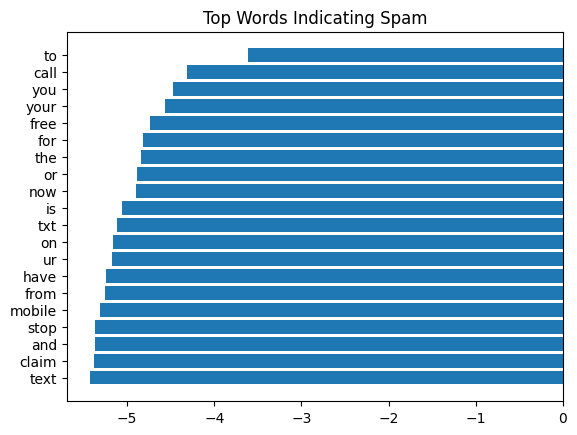

In [71]:
feature_names = vectorizer.get_feature_names_out()
spam_probs = model.feature_log_prob_[1]

top_spam = np.argsort(spam_probs)[-20:]

plt.barh(feature_names[top_spam], spam_probs[top_spam])
plt.title("Top Words Indicating Spam")
plt.show()


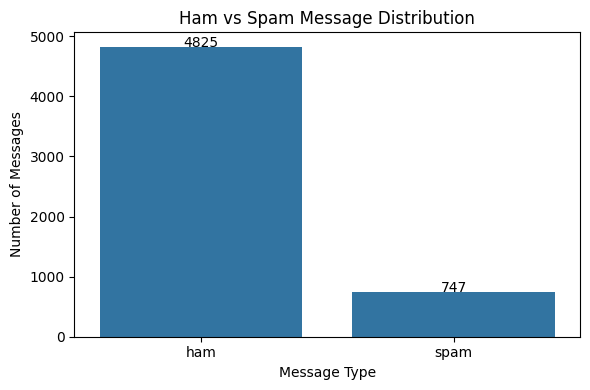

In [72]:
label_counts = df['label'].value_counts()

# Convert to DataFrame (safer for seaborn)
plot_df = label_counts.reset_index()
plot_df.columns = ['label', 'count']

# Plot
plt.figure(figsize=(6,4))
sns.barplot(data=plot_df, x='label', y='count')

plt.title("Ham vs Spam Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

# Add value labels
for i, v in enumerate(plot_df['count']):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

**SCENARIO 2  GAUSSIAN NAÏVE BAYES**

Problem Statement
Classify flower species based on physical measurements.

Dataset (Public / Standard Dataset)
Iris Dataset (sklearn)

Target Variable: Flower Species
Input Features
• Sepal Length
• Sepal Width
• Petal Length
• Petal Width

IN-LAB TASKS (Gaussian Naïve Bayes)
1.	Import required Python libraries.
2.	Load the Iris dataset.
3.	Perform data inspection & preprocessing.
4.	Apply feature scaling.
5.	Split dataset into training and testing sets.
6.	Train a Gaussian Naïve Bayes classifier.
7.	Predict species labels.
8.	Evaluate performance using:
•	Accuracy
•	Precision / Recall / F1 Score
9.	Compare predictions with actual labels.
10.	Analyze class probabilities.
11.	Compare Gaussian NB with Logistic Regression (optional).

Visualization
• Decision Boundary Plot (using two features)
• Confusion Matrix
• Probability distribution plots


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


In [22]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [24]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [25]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [28]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)



GaussianNB()

In [29]:
y_pred = gnb.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))


Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



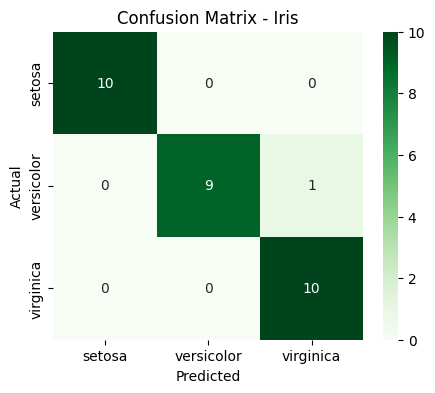

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris")
plt.show()


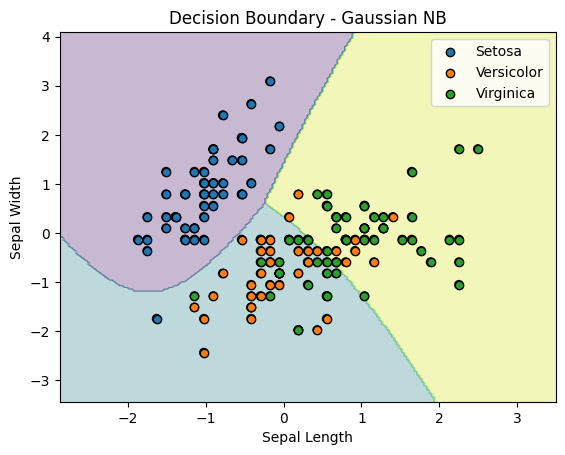

In [38]:
X2 = X_scaled[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.25, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:,0], X2[:,1], c=y, edgecolor='k')
labels = ['Setosa', 'Versicolor', 'Virginica']
for i, label in enumerate(labels):
    plt.scatter(
        X2[y == i, 0],
        X2[y == i, 1],
        label=label,
        edgecolor='k'
    )
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Decision Boundary - Gaussian NB")
plt.legend()
plt.show()


In [33]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.9333333333333333
